In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("cleaned_data.csv")

In [29]:
print(df.head())

print("\nShape:", df.shape)

print("\nData Types")

print(df.dtypes)

   email_id             subject  email_length  num_links  num_exclamations  \
0         1   Claim your reward         161.0        7.0                 2   
1         2        Win cash now         189.0        3.0                 2   
2         3       Free vacation         201.0        5.0                 2   
3         4     Project meeting         177.0        2.0                 1   
4         5  Interview schedule         137.0        0.0                 2   

   capital_letter_percent  has_offer sender_domain  spam_score label  
0                    29.0          1     promo.net         100  spam  
1                    31.0          1   outlook.com          83  spam  
2                    35.0          1   company.com         100  spam  
3                     1.0          0     gmail.com          52   ham  
4                     3.0          0     promo.net          22   ham  

Shape: (600, 10)

Data Types
email_id                    int64
subject                    object
email_l

In [30]:
print(df["label"].unique())

['spam' 'ham']


In [31]:
# Features
X = df.drop(columns=["spam_score", "label"])

# Regression Target
y_reg = df["spam_score"]

# Classification Target
y_clf = df["label"]

print("Feature Shape :", X.shape)
print("Regression Target Shape :", y_reg.shape)
print("Classification Target Shape :", y_clf.shape)

Feature Shape : (600, 8)
Regression Target Shape : (600,)
Classification Target Shape : (600,)


In [32]:
X = pd.get_dummies(
    X,
    columns=["subject", "sender_domain"],
    drop_first=True
)

print(X.head())

   email_id  email_length  num_links  num_exclamations  \
0         1         161.0        7.0                 2   
1         2         189.0        3.0                 2   
2         3         201.0        5.0                 2   
3         4         177.0        2.0                 1   
4         5         137.0        0.0                 2   

   capital_letter_percent  has_offer  subject_Claim your reward  \
0                    29.0          1                       True   
1                    31.0          1                      False   
2                    35.0          1                      False   
3                     1.0          0                      False   
4                     3.0          0                      False   

   subject_Class reminder  subject_Click to verify  subject_Exclusive deal  \
0                   False                    False                   False   
1                   False                    False                   False   
2             

In [33]:
y_clf = y_clf.map({
    "ham": 0,
    "spam": 1
})

print(y_clf.value_counts())

label
0    367
1    233
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

# Regression Split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification Split
_, _, y_clf_train, y_clf_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (480, 26)
Testing Shape : (120, 26)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [36]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_reg_train)

y_pred_reg = linear_model.predict(X_test_scaled)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_reg_test, y_pred_reg)
r2 = r2_score(y_reg_test, y_pred_reg)

print("Mean Squared Error :", mse)
print("R² Score :", r2)

Mean Squared Error : 54.335879945704825
R² Score : 0.9456502268935448


In [38]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values("Absolute", ascending=False)

print(coef_df.head(10))

                          Feature  Coefficient  Absolute
2                       num_links     7.719608  7.719608
8         subject_Click to verify     5.844762  5.844762
20           subject_Win cash now     5.819357  5.819357
1                    email_length     5.269618  5.269618
9          subject_Exclusive deal     5.043726  5.043726
19  subject_Urgent account update     5.003363  5.003363
6       subject_Claim your reward     4.985223  4.985223
4          capital_letter_percent     4.811787  4.811787
14     subject_Limited time offer     4.737584  4.737584
3                num_exclamations     4.448397  4.448397


In [39]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_reg_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error, r2_score

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

print("Ridge MSE :", ridge_mse)
print("Ridge R² :", ridge_r2)

Ridge MSE : 54.27084496666851
Ridge R² : 0.9457152785013984


In [40]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R² Score": [r2, ridge_r2]
})

print(comparison)

               Model        MSE  R² Score
0  Linear Regression  54.335880  0.945650
1   Ridge Regression  54.270845  0.945715


In [41]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_clf_train)

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [42]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Confusion Matrix")
print(confusion_matrix(y_clf_test, y_pred))

print("\nClassification Report")
print(classification_report(y_clf_test, y_pred))

print("\nAccuracy :", accuracy_score(y_clf_test, y_pred))

Confusion Matrix
[[66  0]
 [ 0 54]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66
           1       1.00      1.00      1.00        54

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


Accuracy : 1.0


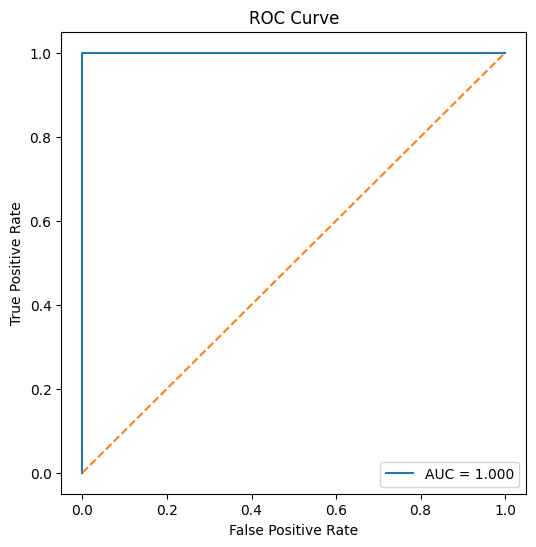

AUC Score : 1.0


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_clf_test, y_prob)

auc = roc_auc_score(y_clf_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score :", auc)

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_clf_test, pred)
    recall = recall_score(y_clf_test, pred)
    f1 = f1_score(y_clf_test, pred)

    results.append([threshold, precision, recall, f1])

threshold_table = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1 Score"]
)

print(threshold_table)

   Threshold  Precision  Recall  F1 Score
0        0.3        1.0     1.0       1.0
1        0.4        1.0     1.0       1.0
2        0.5        1.0     1.0       1.0
3        0.6        1.0     1.0       1.0
4        0.7        1.0     1.0       1.0


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Strongly regularized model
log_model2 = LogisticRegression(C=0.01, max_iter=1000)

log_model2.fit(X_train_scaled, y_clf_train)

pred2 = log_model2.predict(X_test_scaled)
prob2 = log_model2.predict_proba(X_test_scaled)[:, 1]

precision2 = precision_score(y_clf_test, pred2)
recall2 = recall_score(y_clf_test, pred2)
auc2 = roc_auc_score(y_clf_test, prob2)

comparison = pd.DataFrame({
    "Model": ["Logistic (C=1.0)", "Logistic (C=0.01)"],
    "Precision": [precision_score(y_clf_test, y_pred), precision2],
    "Recall": [recall_score(y_clf_test, y_pred), recall2],
    "AUC": [auc, auc2]
})

print(comparison)

               Model  Precision  Recall  AUC
0   Logistic (C=1.0)        1.0     1.0  1.0
1  Logistic (C=0.01)        1.0     1.0  1.0


In [46]:
from sklearn.metrics import roc_auc_score
import numpy as np

auc_diff = []

# Convert y_clf_test to numpy array
y_test_np = y_clf_test.to_numpy()

for i in range(500):

    idx = np.random.choice(
        len(y_test_np),
        size=len(y_test_np),
        replace=True
    )

    # Skip samples that contain only one class
    if len(np.unique(y_test_np[idx])) < 2:
        continue

    auc1 = roc_auc_score(
        y_test_np[idx],
        y_prob[idx]
    )

    auc2 = roc_auc_score(
        y_test_np[idx],
        prob2[idx]
    )

    auc_diff.append(auc1 - auc2)

print("Mean AUC Difference:", np.mean(auc_diff))
print("Lower 2.5%:", np.percentile(auc_diff, 2.5))
print("Upper 97.5%:", np.percentile(auc_diff, 97.5))

Mean AUC Difference: -2.220446049250313e-18
Lower 2.5%: -1.1102230246251565e-16
Upper 97.5%: 1.1102230246251565e-16
